# Heart Disease Prediction — Feature Engineering & Data Preprocessing **AnalystLab Africa | Week 2 | Shylet Nyazika**

 ## Setup

In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

**Part 2:** **Data Inspection**

In [5]:
df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Data Inspection Overview

The dataset contains 918 patient records and 12 columns, combining numeric clinical measurements (Age, RestingBP, Cholesterol, MaxHR, Oldpeak) with categorical fields (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope) and binary indicators (FastingBS, HeartDisease). The target variable is HeartDisease, a binary outcome.

In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0


**Missing Values and Duplicates**

A standard check using isnull().sum() shows 0 missing values, and duplicated().sum() shows 0 duplicate rows. On the surface, this dataset looks complete and clean.

In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
print("Rows with Cholesterol == 0:", (df['Cholesterol'] == 0).sum())
print("Rows with RestingBP == 0:", (df['RestingBP'] == 0).sum())

Rows with Cholesterol == 0: 172
Rows with RestingBP == 0: 1


**Hidden Missing Values**

Looking closer at the summary statistics, both Cholesterol and RestingBP have a minimum value of 0 — which is not medically possible for a living patient. This means missing values exist in this dataset, but they were hidden as zeros instead of blank cells, so the earlier isnull() check missed them. 172 rows (about 19% of the dataset) have Cholesterol == 0, and 1 row has RestingBP == 0. This needs to be treated as missing data and handled before modelling.

**Part 3: Feature Engineering & Data Preprocessing**

**Data Cleaning**

In [10]:
# Treat 0 as missing, then fill with the median (robust to outliers, unlike the mean)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
median_chol = df['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].fillna(median_chol)

print("Remaining zeros in Cholesterol:", (df['Cholesterol'] == 0).sum())
print("Median used to fill:", median_chol)

Remaining zeros in Cholesterol: 0
Median used to fill: 237.0


In [11]:
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())
print("Remaining zeros in RestingBP:", (df['RestingBP'] == 0).sum())

Remaining zeros in RestingBP: 0


**Handling Hidden Missing Values**

The 0 values in Cholesterol and RestingBP were replaced with NaN (marking them as missing), then filled with the median of each column. The median was chosen over the mean because it's less affected by outliers, giving a more realistic "typical" value to substitute in place of the missing readings.

In [12]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows.")

Removed 0 duplicate rows.


**Duplicate Records**

No duplicate rows were found, so no records were removed at this step. This check was still run as a standard part of the cleaning pipeline.

In [13]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,float64
Cholesterol,float64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


**Data Type Validation**

All numeric columns (Age, RestingBP, Cholesterol, MaxHR, Oldpeak) are already stored correctly as int64/float64. FastingBS and HeartDisease are already 0/1 integers. The remaining text columns (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope) are categorical and will be encoded in the next section — no data type corrections were needed.

**Feature Engineering**

In [14]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 40, 55, 100], labels=['Young', 'Middle-aged', 'Senior'])
df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,40,Young
1,49,Middle-aged
2,37,Young
3,48,Middle-aged
4,54,Middle-aged


**New and Renamed Features**

A new feature, AgeGroup, was created by grouping patients into Young (≤40), Middle-aged (41–55), and Senior (56+) categories. This was added because heart disease risk may not increase in a perfectly straight line with age — grouping can help reveal threshold-like patterns a raw age number might not capture on its own. FastingBS and ExerciseAngina were also renamed to FastingBloodSugarHigh and ExerciseInducedAngina for clarity. No columns were removed as irrelevant — unlike a typical business dataset, every field in this clinical dataset has a plausible medical relationship to heart disease risk.

**Feature Encoding**

In [15]:
le = LabelEncoder()

# Rename the column 'ExerciseAngina' to 'ExerciseInducedAngina' as intended
df = df.rename(columns={'ExerciseAngina': 'ExerciseInducedAngina'})

df['Sex'] = le.fit_transform(df['Sex'])
df['ExerciseInducedAngina'] = le.fit_transform(df['ExerciseInducedAngina'])

df[['Sex', 'ExerciseInducedAngina']].head()

,Sex,ExerciseInducedAngina
0,1,0
1,0,0
2,1,0
3,0,1
4,1,0


**Label Encoding**

Sex and ExerciseInducedAngina were converted using Label Encoding, since each only has two possible values (M/F and Y/N). This is safe for binary categories because assigning 0/1 doesn't create any false sense of one value being "greater than" the other.

In [16]:
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope', 'AgeGroup'], drop_first=True)
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseInducedAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,AgeGroup_Middle-aged,AgeGroup_Senior
0,40,1,140.0,289.0,0,172,0,0.0,0,True,False,False,True,False,False,True,False,False
1,49,0,160.0,180.0,0,156,0,1.0,1,False,True,False,True,False,True,False,True,False
2,37,1,130.0,283.0,0,98,0,0.0,0,True,False,False,False,True,False,True,False,False
3,48,0,138.0,214.0,0,108,1,1.5,1,False,False,False,True,False,True,False,True,False
4,54,1,150.0,195.0,0,122,0,0.0,0,False,True,False,True,False,False,True,True,False


**One-Hot Encoding**

ChestPainType, RestingECG, ST_Slope, and AgeGroup were converted using One-Hot Encoding instead, since each has three or more categories with no natural order between them. Label Encoding would have wrongly implied a ranking between categories (e.g. that one chest pain type is numerically "more" than another) — One-Hot avoids that by creating a separate True/False column per category.

**Feature Scaling**

In [17]:
df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']].describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,243.204793,136.809368,0.887364
std,9.432617,17.990127,53.401297,25.460334,1.066570
min,28.000000,80.000000,85.000000,60.000000,-2.600000
25%,47.000000,120.000000,214.000000,120.000000,0.000000
50%,54.000000,130.000000,237.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


In [18]:
scaler = StandardScaler()
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df[numeric_cols].describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02
mean,-1.083616e-16,1.760877e-16,2.399436e-16,4.953675e-16,1.238419e-16
std,1.000545e+00,1.000545e+00,1.000545e+00,1.000545e+00,1.000545e+00
min,-2.706015e+00,-2.921979e+00,-2.964180e+00,-3.018469e+00,-3.271482e+00
25%,-6.906294e-01,-6.973248e-01,-5.471911e-01,-6.605778e-01,-8.324324e-01
50%,5.188098e-02,-1.411613e-01,-1.162551e-01,4.678968e-02,-2.695748e-01
75%,6.883185e-01,4.150021e-01,4.458352e-01,7.541571e-01,5.747115e-01
max,2.491558e+00,3.751983e+00,6.741247e+00,2.561874e+00,4.983762e+00


**Feature Scaling**

Before scaling, Age, RestingBP, Cholesterol, MaxHR, and Oldpeak were all on very different numeric ranges (e.g. Age up to ~77 vs Cholesterol up to 600+). Many machine learning algorithms would wrongly treat larger-scale features as more important. StandardScaler was applied to bring every numeric column to a mean of 0 and standard deviation of 1, since these clinical measurements are roughly normally distributed rather than tightly bounded to a fixed range.

**Outlier Detection**

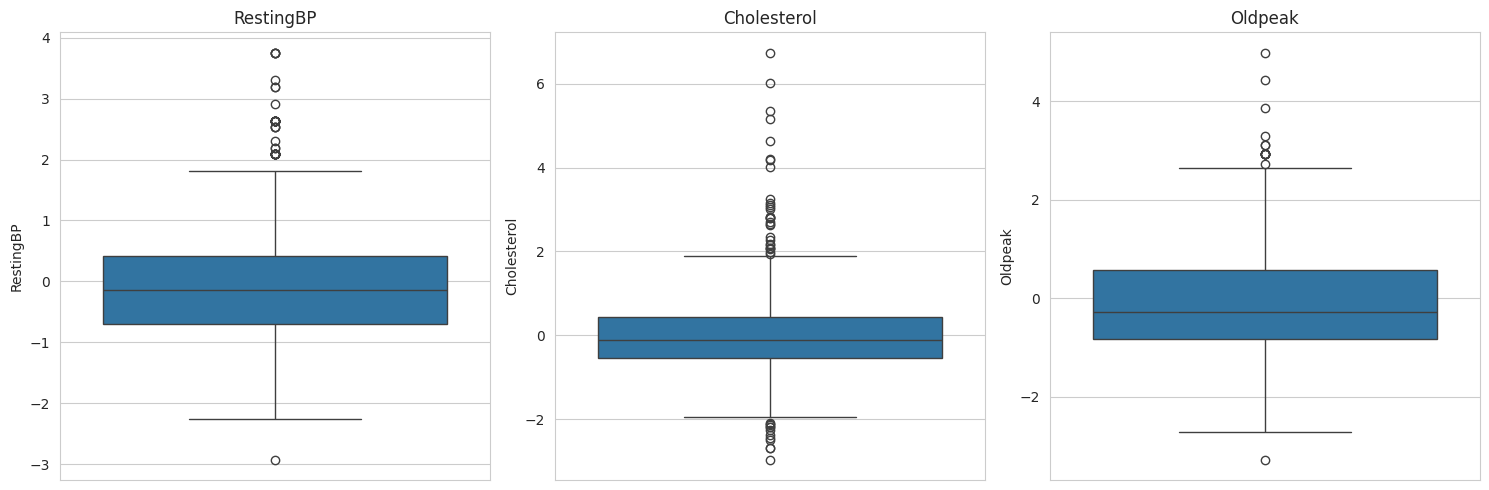

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(y=df['RestingBP'], ax=axes[0]).set_title('RestingBP')
sns.boxplot(y=df['Cholesterol'], ax=axes[1]).set_title('Cholesterol')
sns.boxplot(y=df['Oldpeak'], ax=axes[2]).set_title('Oldpeak')
plt.tight_layout()
plt.show()

**Outlier Detection — Boxplots**

The boxplots show a number of points beyond the whisker range for RestingBP, Cholesterol, and Oldpeak, indicating potential outliers — patients with unusually high readings compared to the rest of the group.

In [20]:
def count_outliers_iqr(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers)

for col in ['RestingBP', 'Cholesterol', 'Oldpeak']:
    print(f"{col}: {count_outliers_iqr(col)} outliers (IQR method)")

RestingBP: 41 outliers (IQR method)
Cholesterol: 41 outliers (IQR method)
Oldpeak: 16 outliers (IQR method)


**Outlier Handling Decision**

The IQR method identified 41 outliers in RestingBP, 41 outliers in Cholesterol, and 16 outliers in Oldpeak. Rather than removing them, the decision was made to keep them — unusually high cholesterol or blood pressure is often a real, clinically meaningful signal in heart disease risk, not a data-entry error, so removing these rows could bias the model against the very high-risk patients it needs to identify.

**Part 4: Feature Selection**

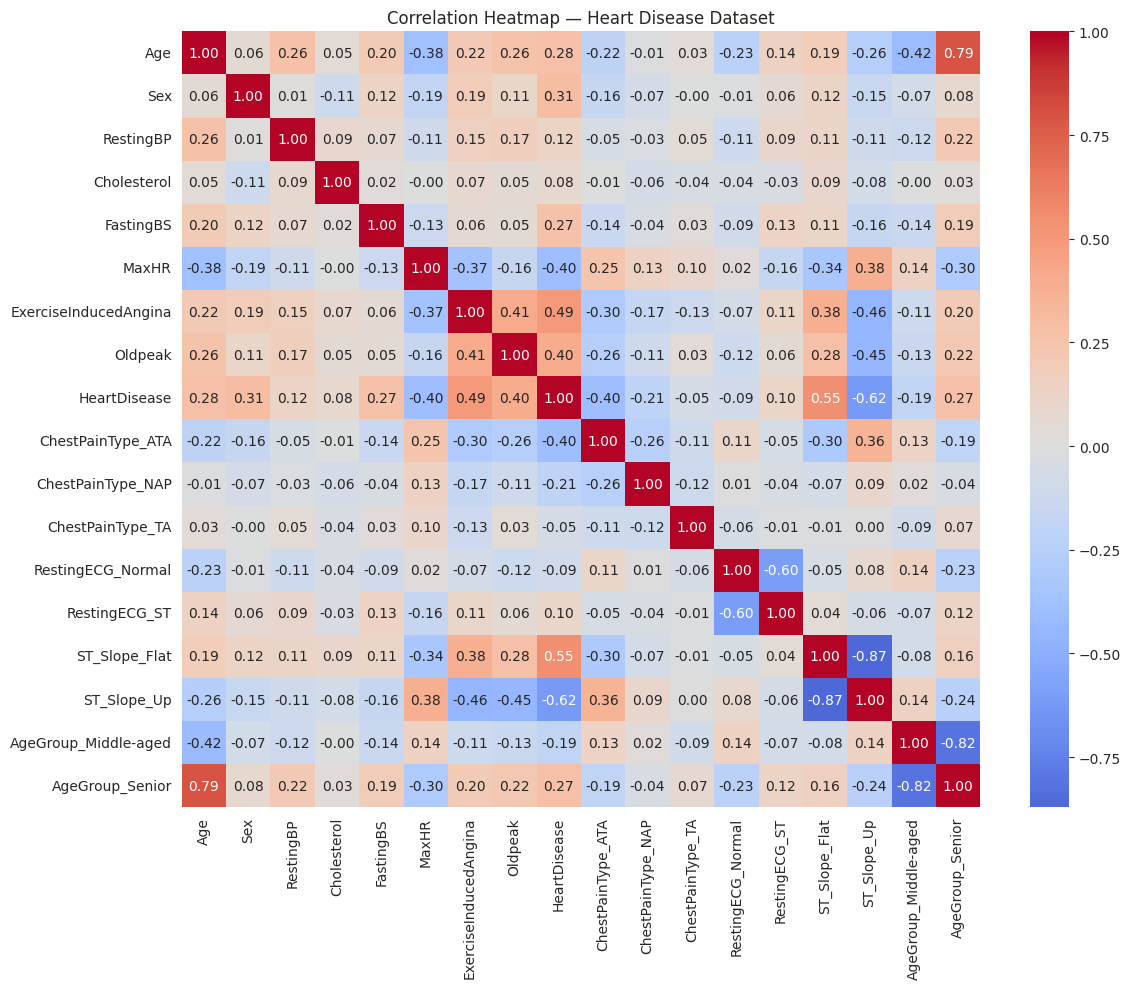

In [21]:
plt.figure(figsize=(12,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Heart Disease Dataset")
plt.tight_layout()
plt.show()

In [22]:
target_corr = corr['HeartDisease'].sort_values(ascending=False)
print(target_corr)

HeartDisease             1.000000
ST_Slope_Flat            0.554134
ExerciseInducedAngina    0.494282
Oldpeak                  0.403951
Sex                      0.305445
Age                      0.282039
AgeGroup_Senior          0.274986
FastingBS                0.267291
RestingBP                0.117798
RestingECG_ST            0.102527
Cholesterol              0.076114
ChestPainType_TA        -0.054790
RestingECG_Normal       -0.091580
AgeGroup_Middle-aged    -0.188566
ChestPainType_NAP       -0.212964
MaxHR                   -0.400421
ChestPainType_ATA       -0.401924
ST_Slope_Up             -0.622164
Name: HeartDisease, dtype: float64


**Feature Selection — Correlation Analysis**

ST_Slope_Flat (0.55), ExerciseInducedAngina (0.49), and Oldpeak (0.40) show the strongest positive correlation with HeartDisease, while ST_Slope_Up (-0.62) and MaxHR (-0.40) show the strongest negative correlation. This suggests that a flat ST slope, exercise-induced angina, and higher Oldpeak values are associated with a higher likelihood of heart disease, while a higher maximum heart rate and an upward-sloping ST segment are associated with a lower likelihood.

No features were removed outright, but two pairs stood out as redundant: ST_Slope_Flat and ST_Slope_Up are strongly negatively correlated with each other (-0.87), and AgeGroup_Senior and AgeGroup_Middle-aged are also strongly negatively correlated (-0.82). This is expected, since both pairs come from One-Hot Encoding the same original column, so this redundancy is mechanical rather than a new finding. More notably, Age and AgeGroup_Senior are highly correlated (0.79), which makes sense since AgeGroup was engineered directly from Age — this is a genuine case of redundant information, since AgeGroup does not add much beyond what Age already captures, and could be considered for removal in a future modelling step to keep the feature set leaner.

**Additional Required Visualizations**

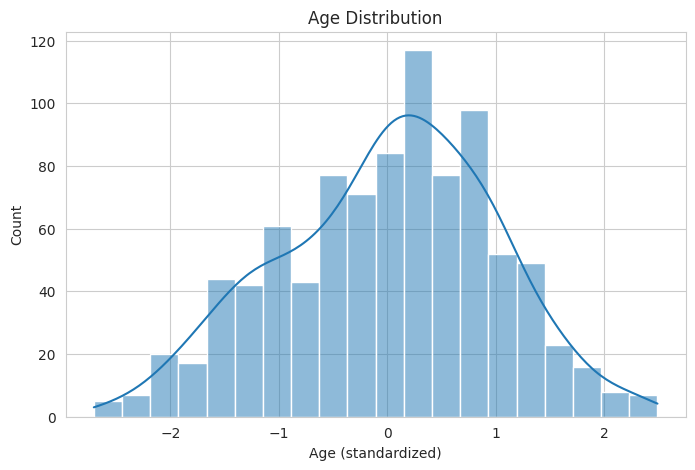

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age (standardized)")
plt.ylabel("Count")
plt.show()

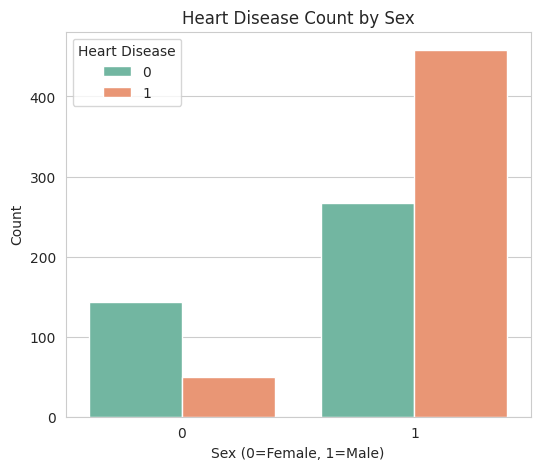

In [24]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Sex', hue='HeartDisease', palette='Set2')
plt.title("Heart Disease Count by Sex")
plt.xlabel("Sex (0=Female, 1=Male)")
plt.ylabel("Count")
plt.legend(title="Heart Disease")
plt.show()

**Additional Visualizations**

The age distribution is roughly bell-shaped (normal), centered around the middle of the standardized range, with most patients falling between roughly -1 and +1 standard deviations of the mean age — consistent with a patient population concentrated in middle age, with fewer very young or very old patients.

The count plot comparing sex and heart disease shows a clear difference between the two groups. Among female patients (Sex = 0), the majority did not have heart disease (roughly 140 vs 50 who did). Among male patients (Sex = 1), the pattern reverses sharply — the majority did have heart disease (roughly 460 vs 265 who did not). This suggests male patients in this dataset have a notably higher proportion of heart disease diagnoses than female patients, consistent with Sex showing a positive correlation (0.31) with HeartDisease in the correlation heatmap.

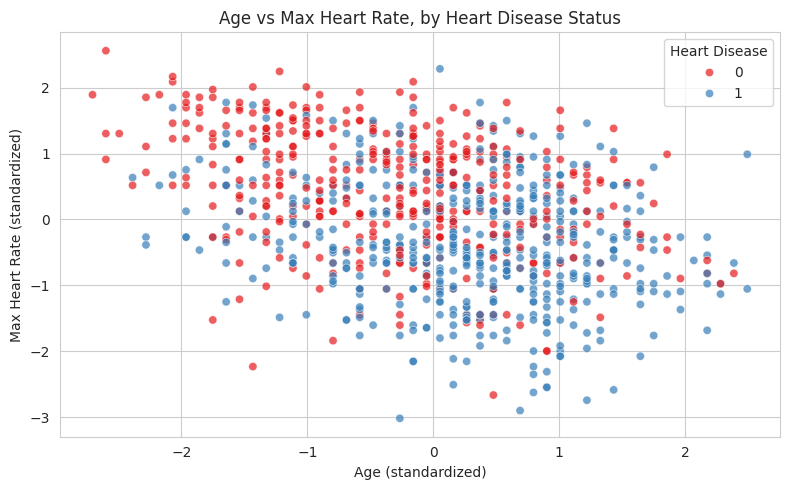

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age', y='MaxHR', hue='HeartDisease', palette='Set1', alpha=0.7)
plt.title("Age vs Max Heart Rate, by Heart Disease Status")
plt.xlabel("Age (standardized)")
plt.ylabel("Max Heart Rate (standardized)")
plt.legend(title="Heart Disease")
plt.tight_layout()
plt.show()

**Scatter Plot — Age vs Max Heart Ra**te **bold text**

Patients with heart disease (blue points, HeartDisease = 1) tend to cluster toward lower Max Heart Rate values compared to patients without heart disease (red points, HeartDisease = 0), who are more concentrated toward the upper half of the chart with higher Max Heart Rate. This pattern holds fairly consistently across the age range, though it becomes more visually distinct from around age 0 (standardized) onward, where blue points increasingly dominate the lower MaxHR region. This is consistent with the negative correlation between MaxHR and HeartDisease seen in the correlation heatmap (-0.40) — a lower maximum heart rate achieved during exercise appears to be associated with a higher likelihood of heart disease in this dataset.

**Part 5: Final Machine Learning Dataset**

In [28]:
df.to_csv("heart_cleaned.csv", index=False)

In [27]:
df.to_csv("heart_ml_ready.csv", index=False)
from google.colab import files
files.download("heart_ml_ready.csv")
files.download("heart_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Preprocessing Summary**

The following steps were applied in order to prepare this dataset for machine learning:

1. Data Cleaning — identified and fixed hidden missing values (0s) in Cholesterol and RestingBP by replacing with the median.
2. Feature Engineering — created an AgeGroup feature and renamed two columns for clarity.
3. Feature Encoding — applied Label Encoding to binary categorical columns and One-Hot Encoding to multi-category columns.
4. Feature Scaling — applied StandardScaler to all continuous numeric columns.
5. Outlier Detection — identified outliers via boxplots and the IQR method, and deliberately retained them due to their clinical relevance.
6. Feature Selection — reviewed a correlation heatmap to identify which features are most associated with HeartDisease and flag any redundant feature pairs.

Is this dataset ready for machine learning? Yes — it has no missing or invalid values, all categorical variables are numerically encoded, and all numeric features are on a comparable scale.